# 6.8 - CertCF density-bias evaluation diagnostics

This notebook tests the density-vs-coverage insight before changing any library code.

It compares three fixed-budget CertCF anchor selectors on the Adult dataset:
- `kmedoids_x`: class-wise `k`-medoids in input space
- `kmedoids_z`: class-wise `k`-medoids in penultimate feature space, mapped back to original training points
- `density_stratified_x`: class-wise density-stratified downsampling in input space

The atlas and query pipeline remain the standard input-space CertCF pipeline for all methods.


In [1]:
from __future__ import annotations

import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import yaml
from IPython.display import display
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors

NOTEBOOK_DIR = Path.cwd().resolve()
ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from certcf import CertCFAtlas, NearestOppositeClassClearanceStrategy
from counterfactuals.benchmarks import create_default_registries
from counterfactuals.utils.clustering import select_prototype_indices
from scripts.benchmark import _build_query_tasks, _build_torch_model_from_checkpoint
from torch.utils.data import TensorDataset

sns.set_theme(style='whitegrid', context='talk')
np.set_printoptions(precision=4, suppress=True)


In [2]:
CONFIG_PATH = ROOT / 'configs/benchmarks/benchmark_meeting_all_200q.yaml'

DATASETS = ['adult']
K_GRID = [100, 200, 300, 500]
ANCHOR_SELECTION_METHODS = ['kmedoids_x', 'kmedoids_z', 'density_stratified_x']
PLOT_SELECTION_METHODS = ['kmedoids_x', 'kmedoids_z']
SELECTION_LABELS = {
    'kmedoids_x': 'k-medoids in input space (X)',
    'kmedoids_z': 'k-medoids in penultimate space (Z)',
    'density_stratified_x': 'density-stratified downsample in input space (X)',
}
SELECTION_SPACE_LABELS = {
    'kmedoids_x': 'input_space',
    'kmedoids_z': 'latent_space',
    'density_stratified_x': 'input_space',
}
LIRPA_METHOD = 'backward'
CERTCF_PARAM_OVERRIDES = {
    'eps_alpha': 0.45,
}
LOW_MARGIN_QUANTILE = 0.10
MAX_COVERAGE_POINTS_PER_CLASS = 4000
COVERAGE_BATCH_SIZE = 128
PILOT_N_QUERIES = 25
DENSITY_SELECTOR_N_NEIGHBORS = 10
DENSITY_SELECTOR_N_BINS = 10
WEIGHTED_KNN_K = 10
MARGIN_GAMMA = 5.0
VISUAL_K = 200
VIS_POINTS_PER_CLASS = 1200
TSNE_POINTS_PER_CLASS = 1000
SEED = 42

print(CONFIG_PATH)
print(DATASETS)
print(K_GRID)
print(ANCHOR_SELECTION_METHODS)
print(LIRPA_METHOD)
print(CERTCF_PARAM_OVERRIDES)
print({
    'density_selector': {'n_neighbors': DENSITY_SELECTOR_N_NEIGHBORS, 'n_bins': DENSITY_SELECTOR_N_BINS},
    'weighted_knn_k': WEIGHTED_KNN_K,
    'margin_gamma': MARGIN_GAMMA,
    'visual_k': VISUAL_K,
})


/home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/configs/benchmarks/benchmark_meeting_all_200q.yaml
['adult']
[100, 200, 300, 500]
['kmedoids_x', 'kmedoids_z', 'density_stratified_x']
backward
{'eps_alpha': 0.45}
{'density_selector': {'n_neighbors': 10, 'n_bins': 10}, 'weighted_knn_k': 10, 'margin_gamma': 5.0, 'visual_k': 200}


In [3]:
with CONFIG_PATH.open() as f:
    BENCHMARK_CFG = yaml.safe_load(f)

DATASET_CFGS = {cfg['name']: cfg for cfg in BENCHMARK_CFG['datasets']}
SHARED_METHOD_CFGS = {cfg['name']: cfg for cfg in BENCHMARK_CFG['methods']}
REGISTRIES = create_default_registries()

missing = sorted(set(DATASETS).difference(DATASET_CFGS))
if missing:
    raise ValueError(f'Unknown datasets in DATASETS: {missing}')


def _norm_to_cdist_metric(norm_value):
    if norm_value == 1:
        return 'cityblock'
    if norm_value == 2:
        return 'euclidean'
    if norm_value == np.inf:
        return 'chebyshev'
    raise ValueError(f'Unsupported norm for cdist conversion: {norm_value!r}')


def _merge_certcf_params(dataset_name):
    params = dict(SHARED_METHOD_CFGS['certcf'].get('params', {}))
    ds_overrides = DATASET_CFGS[dataset_name].get('method_overrides', {}).get('certcf', {})
    params.update(ds_overrides)
    params.update(CERTCF_PARAM_OVERRIDES)
    return params


def _resolve_lirpa_method(method_name):
    return str(method_name).strip().lower().replace('_', '-')


def _resolve_repo_path(path_value):
    path = Path(path_value)
    if path.is_absolute():
        return path
    candidates = [ROOT / path, Path.cwd() / path]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    return (ROOT / path).resolve()


def _batched_logits(model_wrapper, x, batch_size=2048):
    module = model_wrapper.model.eval()
    device = torch.device(model_wrapper.device)
    outputs = []
    with torch.no_grad():
        for start in range(0, len(x), batch_size):
            x_batch = torch.from_numpy(np.asarray(x[start:start + batch_size], dtype=np.float32)).to(device)
            logits = module(x_batch).detach().cpu().numpy()
            outputs.append(logits)
    return np.concatenate(outputs, axis=0)


def _batched_predict_proba(model_wrapper, x, batch_size=2048):
    logits = _batched_logits(model_wrapper, x, batch_size=batch_size)
    logits = logits - logits.max(axis=1, keepdims=True)
    probs = np.exp(logits)
    probs /= probs.sum(axis=1, keepdims=True)
    return probs


def _batched_penultimate_embeddings(model_wrapper, x, batch_size=2048):
    module = model_wrapper.model.eval()
    if not hasattr(module, '__getitem__') or len(module) < 2:
        raise ValueError('Expected a sequential classifier with a final linear layer.')
    feature_extractor = module[:-1]
    final_linear = module[-1]
    if not isinstance(final_linear, torch.nn.Linear):
        raise ValueError('Expected the last classifier layer to be Linear.')

    device = torch.device(model_wrapper.device)
    outputs = []
    with torch.no_grad():
        for start in range(0, len(x), batch_size):
            x_batch = torch.from_numpy(np.asarray(x[start:start + batch_size], dtype=np.float32)).to(device)
            z_batch = feature_extractor(x_batch).detach().cpu().numpy()
            outputs.append(z_batch)
    return np.concatenate(outputs, axis=0)


def _margin_scores(logits, y_true):
    logits = np.asarray(logits, dtype=np.float64)
    y_true = np.asarray(y_true, dtype=np.int64)
    true_scores = logits[np.arange(len(y_true)), y_true]
    masked = logits.copy()
    masked[np.arange(len(y_true)), y_true] = -np.inf
    other_scores = masked.max(axis=1)
    return true_scores - other_scores


def _split_indices_into_strata(cls_idx, margins):
    cls_idx = np.asarray(cls_idx, dtype=np.int64)
    ordered = cls_idx[np.argsort(margins[cls_idx], kind='stable')]
    splits = np.array_split(ordered, 3)
    return {
        'boundary': np.asarray(splits[0], dtype=np.int64),
        'intermediate': np.asarray(splits[1], dtype=np.int64),
        'interior': np.asarray(splits[2], dtype=np.int64),
    }


def _load_dataset_bundle(dataset_name):
    ds_cfg = DATASET_CFGS[dataset_name]
    dataset_params = dict(ds_cfg.get('dataset_params', {'data_dir': 'data/'}))
    dataset_params['data_dir'] = str(_resolve_repo_path(dataset_params.get('data_dir', 'data/')))
    dataset = REGISTRIES['dataset'].create(dataset_name, **dataset_params)
    dataset.load()

    x_train, y_train = dataset.get_train()
    x_test, y_test = dataset.get_test()
    model_cfg = ds_cfg['model']
    if model_cfg['name'] != 'tabular_classifier_ckpt':
        raise ValueError(f"This notebook only supports tabular checkpoint models, got {model_cfg['name']!r}.")

    model_params = dict(model_cfg.get('params', {}))
    model_params['checkpoint'] = str(_resolve_repo_path(model_params['checkpoint']))
    model = _build_torch_model_from_checkpoint(
        checkpoint=model_params['checkpoint'],
        device=model_params.get('device', 'cpu'),
        dataset_module=model_params.get('dataset_module', dataset_name),
        hidden_dims=list(model_params.get('hidden_dims', [32, 8])),
        dropout=float(model_params.get('dropout', 0.2)),
    )

    certcf_params = _merge_certcf_params(dataset_name)
    cert_norm = np.inf if str(certcf_params.get('norm', 2)).lower() in {'inf', 'infinity'} else int(certcf_params.get('norm', 2))
    distance_norm_raw = certcf_params.get('distance_norm', cert_norm)
    distance_norm = np.inf if str(distance_norm_raw).lower() in {'inf', 'infinity'} else int(distance_norm_raw)
    query_method = str(certcf_params.get('query_method', 'sorted')).lower()
    spec = getattr(dataset, 'spec', None)
    ohe_slices = list(spec.categorical_slices) if spec is not None and len(spec.categorical_slices) else None

    x_train = np.asarray(x_train, dtype=np.float32)
    y_train = np.asarray(y_train, dtype=np.int64)
    x_test = np.asarray(x_test, dtype=np.float32)
    y_test = np.asarray(y_test, dtype=np.int64)

    logits = _batched_logits(model, x_train)
    train_probs = _batched_predict_proba(model, x_train)
    margins = _margin_scores(logits, y_train)
    z_train = _batched_penultimate_embeddings(model, x_train)

    return {
        'dataset_name': dataset_name,
        'dataset': dataset,
        'spec': spec,
        'x_train': x_train,
        'y_train': y_train,
        'z_train': np.asarray(z_train, dtype=np.float32),
        'train_probs': np.asarray(train_probs, dtype=np.float32),
        'x_test': x_test,
        'y_test': y_test,
        'model': model,
        'model_cfg': model_cfg,
        'certcf_params': certcf_params,
        'cert_norm': cert_norm,
        'distance_norm': distance_norm,
        'query_method': query_method,
        'ohe_slices': ohe_slices,
        'margin_scores': margins,
        'class_labels': [int(v) for v in np.unique(y_train)],
        'prototype_indices_cache': {},
        'atlas_cache': {},
        'class_strata_cache': {},
        'eval_indices_cache': {},
    }


def _get_class_strata(bundle, class_label):
    cache = bundle['class_strata_cache']
    class_label = int(class_label)
    if class_label in cache:
        return cache[class_label]
    cls_idx = np.where(bundle['y_train'] == class_label)[0]
    strata = _split_indices_into_strata(cls_idx, bundle['margin_scores'])
    cache[class_label] = strata
    return strata


def _selector_space(bundle, selection_method):
    if selection_method == 'kmedoids_x':
        return bundle['x_train']
    if selection_method == 'kmedoids_z':
        return bundle['z_train']
    if selection_method == 'density_stratified_x':
        return bundle['x_train']
    raise ValueError(f'Unknown selection_method: {selection_method!r}')


def _select_within_subset(space_subset, k):
    k = min(int(k), len(space_subset))
    if k <= 0:
        return np.array([], dtype=np.int64)
    if k == len(space_subset):
        return np.arange(len(space_subset), dtype=np.int64)
    return np.asarray(
        select_prototype_indices(space_subset, k=k, method='kmedoids', random_state=SEED),
        dtype=np.int64,
    )


def _knn_distance_scores(X, n_neighbors):
    X = np.asarray(X, dtype=np.float64)
    if len(X) <= 1:
        return np.zeros(len(X), dtype=np.float64)
    n_query_neighbors = min(len(X), max(2, int(n_neighbors) + 1))
    nn = NearestNeighbors(n_neighbors=n_query_neighbors, metric='minkowski', p=2)
    nn.fit(X)
    distances, _ = nn.kneighbors(X)
    kth_dist = distances[:, -1]
    return kth_dist.astype(np.float64)


def _proportional_integer_allocation(bin_sizes, budget):
    bin_sizes = np.asarray(bin_sizes, dtype=np.int64)
    budget = int(budget)
    if budget <= 0 or bin_sizes.sum() == 0:
        return np.zeros_like(bin_sizes)
    if budget >= int(bin_sizes.sum()):
        return bin_sizes.copy()

    raw = budget * (bin_sizes / bin_sizes.sum())
    alloc = np.floor(raw).astype(np.int64)
    remainder = budget - int(alloc.sum())
    frac = raw - alloc

    while remainder > 0:
        candidates = np.where(alloc < bin_sizes)[0]
        if len(candidates) == 0:
            break
        order = candidates[np.argsort(-frac[candidates], kind='stable')]
        for idx in order:
            if remainder <= 0:
                break
            if alloc[idx] < bin_sizes[idx]:
                alloc[idx] += 1
                remainder -= 1
    return alloc


def density_stratified_downsample(X, k, n_neighbors=10, n_bins=10, random_state=SEED):
    X = np.asarray(X, dtype=np.float64)
    k = min(int(k), len(X))
    if k <= 0:
        return np.array([], dtype=np.int64)
    if k == len(X):
        return np.arange(len(X), dtype=np.int64)

    kth_dist = _knn_distance_scores(X, n_neighbors=n_neighbors)
    density = 1.0 / (kth_dist + 1e-12)
    ordered = np.argsort(density, kind='stable')
    bins = [np.asarray(piece, dtype=np.int64) for piece in np.array_split(ordered, min(int(n_bins), len(X)))]
    bin_sizes = np.array([len(piece) for piece in bins], dtype=np.int64)
    alloc = _proportional_integer_allocation(bin_sizes, k)

    rng = np.random.default_rng(random_state)
    selected = []
    for piece, n_pick in zip(bins, alloc):
        if n_pick <= 0:
            continue
        if n_pick >= len(piece):
            chosen = piece
        else:
            chosen = np.sort(rng.choice(piece, size=int(n_pick), replace=False))
        selected.append(np.asarray(chosen, dtype=np.int64))

    if not selected:
        return np.array([], dtype=np.int64)
    return np.sort(np.concatenate(selected).astype(np.int64))


def _get_prototype_indices(bundle, selection_method, k):
    cache = bundle['prototype_indices_cache']
    cache_key = (str(selection_method), int(k))
    if cache_key in cache:
        return cache[cache_key]

    selector_space = _selector_space(bundle, selection_method)
    selected = []
    for class_label in bundle['class_labels']:
        cls_idx = np.where(bundle['y_train'] == class_label)[0]
        k_cls = min(int(k), len(cls_idx))
        if selection_method == 'density_stratified_x':
            local_idx = density_stratified_downsample(
                selector_space[cls_idx],
                k=k_cls,
                n_neighbors=DENSITY_SELECTOR_N_NEIGHBORS,
                n_bins=DENSITY_SELECTOR_N_BINS,
                random_state=SEED + 1000 * int(class_label) + int(k),
            )
        else:
            local_idx = _select_within_subset(selector_space[cls_idx], k_cls)
        selected.append(cls_idx[local_idx])

    absolute_idx = np.concatenate(selected).astype(np.int64)
    cache[cache_key] = absolute_idx
    return absolute_idx


def _get_eval_indices(bundle, class_label, max_points=MAX_COVERAGE_POINTS_PER_CLASS):
    cache_key = (int(class_label), int(max_points) if max_points is not None else None)
    cache = bundle['eval_indices_cache']
    if cache_key in cache:
        return cache[cache_key]

    cls_idx = np.where(bundle['y_train'] == int(class_label))[0]
    if max_points is not None and len(cls_idx) > max_points:
        rng = np.random.default_rng(SEED + 10_000 + int(class_label))
        eval_idx = np.sort(rng.choice(cls_idx, size=max_points, replace=False))
    else:
        eval_idx = cls_idx
    cache[cache_key] = eval_idx
    return eval_idx


def _build_certcf_atlas(bundle, selection_method, k):
    cache = bundle['atlas_cache']
    cache_key = (str(selection_method), int(k))
    if cache_key in cache:
        return cache[cache_key]

    selected_idx = _get_prototype_indices(bundle, selection_method, k)
    x_proto = bundle['x_train'][selected_idx]
    y_proto = bundle['y_train'][selected_idx]
    params = bundle['certcf_params']

    atlas = CertCFAtlas(
        model=bundle['model'].model,
        dataset=TensorDataset(torch.from_numpy(x_proto).float(), torch.from_numpy(y_proto).long()),
        device=bundle['model'].device,
        cnn=False,
        norm=bundle['cert_norm'],
        distance_norm=bundle['distance_norm'],
        eps_strategy=NearestOppositeClassClearanceStrategy(alpha=float(bundle['certcf_params'].get('eps_alpha', CERTCF_PARAM_OVERRIDES.get('eps_alpha', 0.25)))),
        batch_size=int(params.get('batch_size', 256)),
        ohe_slices=bundle['ohe_slices'],
        default_query_method=bundle['query_method'],
        solver_maxiter=int(params.get('solver_maxiter', 500)),
        lirpa_method=_resolve_lirpa_method(LIRPA_METHOD),
    )

    t0 = time.perf_counter()
    atlas.build(verbose=False)
    build_time_s = time.perf_counter() - t0
    cache[cache_key] = (atlas, build_time_s, selected_idx)
    return cache[cache_key]


def _summary_stats(values):
    values = np.asarray(values, dtype=np.float64)
    if len(values) == 0:
        return {
            'n_points': 0,
            'mean_distance': np.nan,
            'median_distance': np.nan,
            'p90_distance': np.nan,
            'p95_distance': np.nan,
        }
    return {
        'n_points': int(len(values)),
        'mean_distance': float(np.mean(values)),
        'median_distance': float(np.median(values)),
        'p90_distance': float(np.quantile(values, 0.90)),
        'p95_distance': float(np.quantile(values, 0.95)),
    }


def _selection_summary_rows(bundle, selection_method, k):
    y_train = bundle['y_train']
    margins = bundle['margin_scores']
    selected_idx = _get_prototype_indices(bundle, selection_method, k)

    rows = []
    total_counts = {'boundary': 0, 'intermediate': 0, 'interior': 0}
    for class_label in bundle['class_labels']:
        strata = _get_class_strata(bundle, int(class_label))
        class_selected = selected_idx[y_train[selected_idx] == int(class_label)]
        row = {
            'dataset': bundle['dataset_name'],
            'selection_method': selection_method,
            'selection_label': SELECTION_LABELS[selection_method],
            'selection_space': SELECTION_SPACE_LABELS[selection_method],
            'class_label': int(class_label),
            'k_per_class': int(k),
            'n_selected': int(len(class_selected)),
            'selected_margin_mean': float(np.mean(margins[class_selected])) if len(class_selected) else np.nan,
            'selected_margin_median': float(np.median(margins[class_selected])) if len(class_selected) else np.nan,
        }
        for name in ['boundary', 'intermediate', 'interior']:
            count = int(np.isin(class_selected, strata[name]).sum())
            row[f'n_{name}'] = count
            total_counts[name] += count
        rows.append(row)

    rows.append({
        'dataset': bundle['dataset_name'],
        'selection_method': selection_method,
        'selection_label': SELECTION_LABELS[selection_method],
        'selection_space': SELECTION_SPACE_LABELS[selection_method],
        'class_label': 'overall',
        'k_per_class': int(k),
        'n_selected': int(len(selected_idx)),
        'selected_margin_mean': float(np.mean(margins[selected_idx])) if len(selected_idx) else np.nan,
        'selected_margin_median': float(np.median(margins[selected_idx])) if len(selected_idx) else np.nan,
        'n_boundary': int(total_counts['boundary']),
        'n_intermediate': int(total_counts['intermediate']),
        'n_interior': int(total_counts['interior']),
    })
    return rows


def _prototype_distance_rows(bundle, selection_method, k):
    y_train = bundle['y_train']
    margins = bundle['margin_scores']
    selected_idx = _get_prototype_indices(bundle, selection_method, k)
    selector_space = _selector_space(bundle, selection_method)
    metric = _norm_to_cdist_metric(bundle['cert_norm'])

    rows = []
    overall_dists = []
    overall_low_margin_dists = []

    for class_label in bundle['class_labels']:
        cls_idx = np.where(y_train == class_label)[0]
        proto_idx = selected_idx[y_train[selected_idx] == class_label]
        cls_dists = cdist(selector_space[cls_idx], selector_space[proto_idx], metric=metric).min(axis=1)
        overall_dists.append(cls_dists)

        class_threshold = np.quantile(margins[cls_idx], LOW_MARGIN_QUANTILE)
        low_margin_mask = margins[cls_idx] <= class_threshold
        low_margin_dists = cls_dists[low_margin_mask]
        overall_low_margin_dists.append(low_margin_dists)

        for subset_name, subset_dists in [('all', cls_dists), ('low_margin', low_margin_dists)]:
            row = {
                'dataset': bundle['dataset_name'],
                'selection_method': selection_method,
                'selection_label': SELECTION_LABELS[selection_method],
                'selection_space': SELECTION_SPACE_LABELS[selection_method],
                'class_label': int(class_label),
                'k_per_class': int(k),
                'subset': subset_name,
                'n_prototypes_for_class': int(len(proto_idx)),
            }
            row.update(_summary_stats(subset_dists))
            rows.append(row)

    for subset_name, pieces in [('all', overall_dists), ('low_margin', overall_low_margin_dists)]:
        merged = np.concatenate([piece for piece in pieces if len(piece) > 0]) if pieces else np.array([], dtype=np.float64)
        row = {
            'dataset': bundle['dataset_name'],
            'selection_method': selection_method,
            'selection_label': SELECTION_LABELS[selection_method],
            'selection_space': SELECTION_SPACE_LABELS[selection_method],
            'class_label': 'overall',
            'k_per_class': int(k),
            'subset': subset_name,
            'n_prototypes_for_class': int(k),
        }
        row.update(_summary_stats(merged))
        rows.append(row)

    return rows


def _certified_membership_mask(atlas, class_label, x_eval):
    x_eval = np.asarray(x_eval, dtype=np.float64)
    mask = np.zeros(len(x_eval), dtype=bool)
    for i, x in enumerate(x_eval):
        result = atlas.verify_counterfactual(x, int(class_label), delta=0.0)
        mask[i] = bool(result['in_certified_polytope'])
    return mask


def _certified_cover_counts(atlas, class_label, x_eval):
    bd = atlas.bounds[int(class_label)]
    counts = np.zeros(len(x_eval), dtype=np.int64)
    for anchor_idx in range(len(bd['X'])):
        for i, x in enumerate(x_eval):
            nominal_ok, _ = atlas._polytope_membership_for_anchor(
                np.asarray(x, dtype=np.float64),
                bd,
                anchor_idx,
                delta=0.0,
                robust_norm=atlas.norm,
            )
            if nominal_ok:
                counts[i] += 1
    return counts


def _coverage_rows(bundle, selection_method, k):
    atlas, build_time_s, selected_idx = _build_certcf_atlas(bundle, selection_method, k)
    x_train = bundle['x_train']
    rows = []
    total_eval = 0
    total_covered = 0

    for class_label in bundle['class_labels']:
        eval_idx = _get_eval_indices(bundle, int(class_label))
        covered = _certified_membership_mask(atlas, int(class_label), x_train[eval_idx])
        total_eval += int(len(eval_idx))
        total_covered += int(covered.sum())
        rows.append({
            'dataset': bundle['dataset_name'],
            'selection_method': selection_method,
            'selection_label': SELECTION_LABELS[selection_method],
            'selection_space': SELECTION_SPACE_LABELS[selection_method],
            'class_label': int(class_label),
            'k_per_class': int(k),
            'n_eval': int(len(eval_idx)),
            'n_covered': int(covered.sum()),
            'coverage_rate': float(covered.mean()),
            'build_time_s': float(build_time_s),
            'n_selected_total': int(len(selected_idx)),
        })

    rows.append({
        'dataset': bundle['dataset_name'],
        'selection_method': selection_method,
        'selection_label': SELECTION_LABELS[selection_method],
        'selection_space': SELECTION_SPACE_LABELS[selection_method],
        'class_label': 'overall',
        'k_per_class': int(k),
        'n_eval': int(total_eval),
        'n_covered': int(total_covered),
        'coverage_rate': float(total_covered / total_eval) if total_eval else np.nan,
        'build_time_s': float(build_time_s),
        'n_selected_total': int(len(selected_idx)),
    })
    return rows


def _overlap_rows(bundle, selection_method, k):
    atlas, build_time_s, selected_idx = _build_certcf_atlas(bundle, selection_method, k)
    x_train = bundle['x_train']
    rows = []
    total_eval = 0
    total_cover_counts = []

    for class_label in bundle['class_labels']:
        eval_idx = _get_eval_indices(bundle, int(class_label))
        cover_counts = _certified_cover_counts(atlas, int(class_label), x_train[eval_idx])
        covered_mask = cover_counts > 0
        multi_mask = cover_counts >= 2
        overlap_excess = np.maximum(cover_counts - 1, 0)

        total_eval += int(len(eval_idx))
        total_cover_counts.append(cover_counts)
        rows.append({
            'dataset': bundle['dataset_name'],
            'selection_method': selection_method,
            'selection_label': SELECTION_LABELS[selection_method],
            'selection_space': SELECTION_SPACE_LABELS[selection_method],
            'class_label': int(class_label),
            'k_per_class': int(k),
            'n_eval': int(len(eval_idx)),
            'covered_rate': float(covered_mask.mean()),
            'multi_cover_rate': float(multi_mask.mean()),
            'mean_cover_count': float(np.mean(cover_counts)),
            'mean_cover_count_if_covered': float(np.mean(cover_counts[covered_mask])) if covered_mask.any() else np.nan,
            'mean_overlap_excess': float(np.mean(overlap_excess)),
            'build_time_s': float(build_time_s),
            'n_selected_total': int(len(selected_idx)),
        })

    merged = np.concatenate(total_cover_counts) if total_cover_counts else np.array([], dtype=np.int64)
    covered_mask = merged > 0
    multi_mask = merged >= 2
    overlap_excess = np.maximum(merged - 1, 0)
    rows.append({
        'dataset': bundle['dataset_name'],
        'selection_method': selection_method,
        'selection_label': SELECTION_LABELS[selection_method],
        'selection_space': SELECTION_SPACE_LABELS[selection_method],
        'class_label': 'overall',
        'k_per_class': int(k),
        'n_eval': int(total_eval),
        'covered_rate': float(covered_mask.mean()) if len(merged) else np.nan,
        'multi_cover_rate': float(multi_mask.mean()) if len(merged) else np.nan,
        'mean_cover_count': float(np.mean(merged)) if len(merged) else np.nan,
        'mean_cover_count_if_covered': float(np.mean(merged[covered_mask])) if covered_mask.any() else np.nan,
        'mean_overlap_excess': float(np.mean(overlap_excess)) if len(merged) else np.nan,
        'build_time_s': float(build_time_s),
        'n_selected_total': int(len(selected_idx)),
    })
    return rows


def _weighted_mean(values, weights):
    values = np.asarray(values, dtype=np.float64)
    weights = np.asarray(weights, dtype=np.float64)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    if not valid.any():
        return np.nan
    return float(np.average(values[valid], weights=weights[valid]))


def _inverse_density_weights(x_eval, x_reference, knn_k=WEIGHTED_KNN_K):
    x_eval = np.asarray(x_eval, dtype=np.float64)
    x_reference = np.asarray(x_reference, dtype=np.float64)
    if len(x_reference) == 0:
        return np.ones(len(x_eval), dtype=np.float64)
    n_neighbors = min(int(knn_k), len(x_reference))
    n_neighbors = max(1, n_neighbors)
    nn = NearestNeighbors(n_neighbors=n_neighbors, metric='minkowski', p=2)
    nn.fit(x_reference)
    distances, _ = nn.kneighbors(x_eval)
    kth_dist = distances[:, -1]
    weights = kth_dist + 1e-12
    mean_w = float(np.mean(weights)) if len(weights) else 1.0
    if mean_w > 0:
        weights = weights / mean_w
    return weights.astype(np.float64)


def _margin_weights_from_probs(target_probs, gamma=MARGIN_GAMMA):
    target_probs = np.asarray(target_probs, dtype=np.float64)
    weights = np.exp(-float(gamma) * np.abs(target_probs - 0.5))
    mean_w = float(np.mean(weights)) if len(weights) else 1.0
    if mean_w > 0:
        weights = weights / mean_w
    return weights.astype(np.float64)


def _weighted_support_rows(bundle, selection_method, k):
    atlas, build_time_s, selected_idx = _build_certcf_atlas(bundle, selection_method, k)
    x_train = bundle['x_train']
    train_probs = bundle['train_probs']
    rows = []

    overall_covered = []
    overall_cover_counts = []
    overall_overlap_excess = []
    overall_inv_weights = []
    overall_margin_weights = []

    for class_label in bundle['class_labels']:
        eval_idx = _get_eval_indices(bundle, int(class_label))
        x_eval = x_train[eval_idx]
        cover_counts = _certified_cover_counts(atlas, int(class_label), x_eval)
        covered = (cover_counts > 0).astype(np.float64)
        overlap_excess = np.maximum(cover_counts - 1, 0).astype(np.float64)
        target_probs = train_probs[eval_idx, int(class_label)]

        inv_weights = _inverse_density_weights(
            x_eval,
            x_train[bundle['y_train'] == int(class_label)],
            knn_k=WEIGHTED_KNN_K,
        )
        margin_weights = _margin_weights_from_probs(target_probs, gamma=MARGIN_GAMMA)

        overall_covered.append(covered)
        overall_cover_counts.append(cover_counts.astype(np.float64))
        overall_overlap_excess.append(overlap_excess)
        overall_inv_weights.append(inv_weights)
        overall_margin_weights.append(margin_weights)

        rows.append({
            'dataset': bundle['dataset_name'],
            'selection_method': selection_method,
            'selection_label': SELECTION_LABELS[selection_method],
            'selection_space': SELECTION_SPACE_LABELS[selection_method],
            'class_label': int(class_label),
            'k_per_class': int(k),
            'n_eval': int(len(eval_idx)),
            'coverage_rate_inverse_density': _weighted_mean(covered, inv_weights),
            'coverage_rate_margin_weighted': _weighted_mean(covered, margin_weights),
            'mean_cover_count_inverse_density': _weighted_mean(cover_counts.astype(np.float64), inv_weights),
            'mean_cover_count_margin_weighted': _weighted_mean(cover_counts.astype(np.float64), margin_weights),
            'mean_overlap_excess_inverse_density': _weighted_mean(overlap_excess, inv_weights),
            'mean_overlap_excess_margin_weighted': _weighted_mean(overlap_excess, margin_weights),
            'inverse_density_weight_mean': float(np.mean(inv_weights)),
            'margin_weight_mean': float(np.mean(margin_weights)),
            'build_time_s': float(build_time_s),
            'n_selected_total': int(len(selected_idx)),
        })

    rows.append({
        'dataset': bundle['dataset_name'],
        'selection_method': selection_method,
        'selection_label': SELECTION_LABELS[selection_method],
        'selection_space': SELECTION_SPACE_LABELS[selection_method],
        'class_label': 'overall',
        'k_per_class': int(k),
        'n_eval': int(sum(len(v) for v in overall_covered)),
        'coverage_rate_inverse_density': _weighted_mean(np.concatenate(overall_covered), np.concatenate(overall_inv_weights)),
        'coverage_rate_margin_weighted': _weighted_mean(np.concatenate(overall_covered), np.concatenate(overall_margin_weights)),
        'mean_cover_count_inverse_density': _weighted_mean(np.concatenate(overall_cover_counts), np.concatenate(overall_inv_weights)),
        'mean_cover_count_margin_weighted': _weighted_mean(np.concatenate(overall_cover_counts), np.concatenate(overall_margin_weights)),
        'mean_overlap_excess_inverse_density': _weighted_mean(np.concatenate(overall_overlap_excess), np.concatenate(overall_inv_weights)),
        'mean_overlap_excess_margin_weighted': _weighted_mean(np.concatenate(overall_overlap_excess), np.concatenate(overall_margin_weights)),
        'inverse_density_weight_mean': float(np.mean(np.concatenate(overall_inv_weights))),
        'margin_weight_mean': float(np.mean(np.concatenate(overall_margin_weights))),
        'build_time_s': float(build_time_s),
        'n_selected_total': int(len(selected_idx)),
    })
    return rows


def _pilot_query_rows(bundle, selection_method, k):
    atlas, build_time_s, selected_idx = _build_certcf_atlas(bundle, selection_method, k)
    query_indices, y_true, y_orig, target_classes = _build_query_tasks(
        dataset_name=bundle['dataset_name'],
        x_test=bundle['x_test'],
        y_test=bundle['y_test'],
        model=bundle['model'],
        sampling_cfg={'n_queries': int(PILOT_N_QUERIES)},
        rng=np.random.default_rng(SEED),
    )

    if target_classes is None:
        n_classes = int(bundle['model'].predict_proba(bundle['x_test'][:1]).shape[1])
        if n_classes != 2:
            raise ValueError(
                f"Pilot query analysis requires explicit target classes for non-binary dataset {bundle['dataset_name']!r}."
            )
        target_classes = 1 - np.asarray(y_orig, dtype=np.int64)

    rows = []
    for query_idx, y_true_i, y_orig_i, target_class in zip(query_indices, y_true, y_orig, target_classes):
        x_query = bundle['x_test'][query_idx]
        source_probs = np.asarray(bundle['model'].predict_proba(x_query[None, :])[0], dtype=np.float64)
        source_target_prob = float(source_probs[int(target_class)])
        margin_weight = float(_margin_weights_from_probs(np.array([source_target_prob]), gamma=MARGIN_GAMMA)[0])
        result = atlas.find_counterfactual(
            x_query=x_query,
            target_class=int(target_class),
            method=bundle['query_method'],
        )
        rows.append({
            'dataset': bundle['dataset_name'],
            'selection_method': selection_method,
            'selection_label': SELECTION_LABELS[selection_method],
            'selection_space': SELECTION_SPACE_LABELS[selection_method],
            'k_per_class': int(k),
            'query_idx': int(query_idx),
            'y_true': int(y_true_i),
            'y_orig': int(y_orig_i),
            'target_class': int(target_class),
            'source_target_prob': source_target_prob,
            'margin_weight': margin_weight,
            'success': bool(result.success),
            'distance': float(result.distance) if result.success else np.nan,
            'query_time_ms': float(result.profiling.get('total_time_ms', np.nan)),
            'build_time_s': float(build_time_s),
            'n_selected_total': int(len(selected_idx)),
        })
    return rows


def _pilot_summary_from_df(pilot_df):
    rows = []
    group_cols = ['dataset', 'selection_method', 'selection_label', 'selection_space', 'k_per_class']
    for keys, group in pilot_df.groupby(group_cols, as_index=False):
        key_map = dict(zip(group_cols, keys if isinstance(keys, tuple) else (keys,)))
        rows.append({
            **key_map,
            'success_rate': float(group['success'].mean()),
            'mean_distance': float(group['distance'].mean()),
            'median_distance': float(group['distance'].median()),
            'pilot_mean_distance_margin_weighted': _weighted_mean(group['distance'].to_numpy(dtype=np.float64), group['margin_weight'].to_numpy(dtype=np.float64)),
            'mean_query_time_ms': float(group['query_time_ms'].mean()),
            'median_query_time_ms': float(group['query_time_ms'].median()),
            'build_time_s': float(group['build_time_s'].mean()),
        })
    return pd.DataFrame(rows)


def _make_comparison_table(selection_overall, compression_overall, coverage_overall, overlap_overall, weighted_overall, pilot_summary):
    compression_pivot = compression_overall[
        ['dataset', 'selection_method', 'selection_label', 'selection_space', 'k_per_class', 'subset', 'p95_distance', 'mean_distance']
    ].pivot(
        index=['dataset', 'selection_method', 'selection_label', 'selection_space', 'k_per_class'],
        columns='subset',
        values=['p95_distance', 'mean_distance'],
    ).reset_index()
    compression_pivot.columns = [
        '_'.join([str(x) for x in col if x != '']).strip('_') if isinstance(col, tuple) else col
        for col in compression_pivot.columns
    ]

    comparison_df = (
        coverage_overall[['dataset', 'selection_method', 'selection_label', 'selection_space', 'k_per_class', 'coverage_rate']]
        .merge(
            overlap_overall[['dataset', 'selection_method', 'selection_label', 'selection_space', 'k_per_class', 'multi_cover_rate', 'mean_overlap_excess']],
            on=['dataset', 'selection_method', 'selection_label', 'selection_space', 'k_per_class'],
            how='left',
        )
        .merge(
            weighted_overall[[
                'dataset', 'selection_method', 'selection_label', 'selection_space', 'k_per_class',
                'coverage_rate_inverse_density', 'coverage_rate_margin_weighted',
                'mean_overlap_excess_inverse_density', 'mean_overlap_excess_margin_weighted'
            ]],
            on=['dataset', 'selection_method', 'selection_label', 'selection_space', 'k_per_class'],
            how='left',
        )
        .merge(
            compression_pivot,
            on=['dataset', 'selection_method', 'selection_label', 'selection_space', 'k_per_class'],
            how='left',
        )
        .merge(
            pilot_summary[[
                'dataset', 'selection_method', 'selection_label', 'selection_space', 'k_per_class',
                'success_rate', 'mean_distance', 'median_distance', 'pilot_mean_distance_margin_weighted',
                'mean_query_time_ms', 'median_query_time_ms', 'build_time_s'
            ]].rename(columns={
                'mean_distance': 'pilot_mean_distance',
                'median_distance': 'pilot_median_distance',
            }),
            on=['dataset', 'selection_method', 'selection_label', 'selection_space', 'k_per_class'],
            how='left',
        )
    )

    baseline = comparison_df[comparison_df['selection_method'] == 'kmedoids_x'].copy()
    variant_rows = comparison_df[comparison_df['selection_method'] != 'kmedoids_x'].copy()
    merged = baseline.merge(
        variant_rows,
        on=['dataset', 'k_per_class'],
        suffixes=('_baseline', '_variant'),
    )

    delta_cols = [
        'coverage_rate', 'coverage_rate_inverse_density', 'coverage_rate_margin_weighted',
        'multi_cover_rate', 'mean_overlap_excess', 'mean_overlap_excess_inverse_density', 'mean_overlap_excess_margin_weighted',
        'mean_distance_all', 'p95_distance_all', 'mean_distance_low_margin', 'p95_distance_low_margin',
        'success_rate', 'pilot_mean_distance', 'pilot_median_distance', 'pilot_mean_distance_margin_weighted',
        'mean_query_time_ms', 'median_query_time_ms', 'build_time_s',
    ]
    for col in delta_cols:
        merged[f'delta_{col}'] = merged[f'{col}_variant'] - merged[f'{col}_baseline']
    return merged


def _sample_support_indices(bundle, n_per_class, seed_offset=0):
    rng = np.random.default_rng(SEED + seed_offset)
    selected = []
    for class_label in bundle['class_labels']:
        cls_idx = np.where(bundle['y_train'] == int(class_label))[0]
        n_pick = min(int(n_per_class), len(cls_idx))
        picked = np.sort(rng.choice(cls_idx, size=n_pick, replace=False)) if n_pick < len(cls_idx) else cls_idx
        selected.append(picked.astype(np.int64))
    return np.concatenate(selected).astype(np.int64)


def _visual_union_indices(bundle, visual_k, n_support_per_class, methods=None):
    if methods is None:
        methods = PLOT_SELECTION_METHODS
    support_idx = _sample_support_indices(bundle, n_support_per_class, seed_offset=888)
    selected_sets = [_get_prototype_indices(bundle, method, visual_k) for method in methods]
    merged = np.unique(np.concatenate([support_idx] + selected_sets)).astype(np.int64)
    return merged


def _plot_support_with_anchors(ax, support_coords, support_labels, anchor_coords, anchor_labels, title):
    palette_support = {0: '#9ecae1', 1: '#fdd0a2'}
    palette_anchor = {0: '#08519c', 1: '#a63603'}
    for class_label in sorted(np.unique(support_labels)):
        subset = support_coords[np.asarray(support_labels) == class_label]
        ax.scatter(subset[:, 0], subset[:, 1], s=14, alpha=0.22, c=palette_support.get(int(class_label), '#cccccc'), label=f'Support class {class_label}')
    for class_label in sorted(np.unique(anchor_labels)):
        subset = anchor_coords[np.asarray(anchor_labels) == class_label]
        ax.scatter(subset[:, 0], subset[:, 1], s=70, marker='X', linewidths=0.8, edgecolors='black', c=palette_anchor.get(int(class_label), '#111111'), label=f'Anchor class {class_label}')
    ax.set_title(title)
    ax.set_xlabel('dim 1')
    ax.set_ylabel('dim 2')
    handles, labels = ax.get_legend_handles_labels()
    dedup = dict(zip(labels, handles))
    ax.legend(dedup.values(), dedup.keys(), loc='best', frameon=True, fontsize=10)


def _plot_penultimate_tsne_views(bundle, visual_k):
    support_idx = _sample_support_indices(bundle, n_per_class=VIS_POINTS_PER_CLASS, seed_offset=777)
    tsne_union_idx = _visual_union_indices(bundle, visual_k, n_support_per_class=TSNE_POINTS_PER_CLASS, methods=PLOT_SELECTION_METHODS)
    tsne_z = bundle['z_train'][tsne_union_idx]
    latent_tsne = TSNE(
        n_components=2,
        random_state=SEED,
        init='pca',
        learning_rate='auto',
        perplexity=min(35, max(5, (len(tsne_z) - 1) // 3)),
    )
    tsne_coords = latent_tsne.fit_transform(tsne_z)
    tsne_lookup = {int(idx): tsne_coords[i] for i, idx in enumerate(tsne_union_idx)}
    support_coords = np.vstack([tsne_lookup[int(idx)] for idx in support_idx if int(idx) in tsne_lookup])
    support_labels = np.asarray([bundle['y_train'][idx] for idx in support_idx if int(idx) in tsne_lookup], dtype=np.int64)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)
    for ax, selection_method in zip(axes, PLOT_SELECTION_METHODS):
        selected_idx = _get_prototype_indices(bundle, selection_method, visual_k)
        anchor_y = bundle['y_train'][selected_idx]
        anchor_coords = np.vstack([tsne_lookup[int(idx)] for idx in selected_idx])
        _plot_support_with_anchors(
            ax,
            support_coords=support_coords,
            support_labels=support_labels,
            anchor_coords=anchor_coords,
            anchor_labels=anchor_y,
            title=f'Penultimate t-SNE - {SELECTION_LABELS[selection_method]}',
        )
    plt.tight_layout()
    plt.show()


In [4]:
bundles = {dataset_name: _load_dataset_bundle(dataset_name) for dataset_name in DATASETS}

overview_rows = []
for dataset_name, bundle in bundles.items():
    class_counts = pd.Series(bundle['y_train']).value_counts().sort_index().to_dict()
    overview_rows.append({
        'dataset': dataset_name,
        'n_train': int(len(bundle['x_train'])),
        'n_test': int(len(bundle['x_test'])),
        'classes': class_counts,
        'input_dim': int(bundle['x_train'].shape[1]),
        'latent_dim': int(bundle['z_train'].shape[1]),
        'cert_norm': bundle['cert_norm'],
        'distance_norm': bundle['distance_norm'],
        'eps_alpha': float(bundle['certcf_params'].get('eps_alpha', CERTCF_PARAM_OVERRIDES.get('eps_alpha', 0.25))),
        'query_method': bundle['query_method'],
        'lirpa_method': _resolve_lirpa_method(LIRPA_METHOD),
        'selection_methods': ', '.join(SELECTION_LABELS[name] for name in ANCHOR_SELECTION_METHODS),
    })

display(pd.DataFrame(overview_rows))


,dataset,n_train,n_test,classes,input_dim,latent_dim,cert_norm,distance_norm,eps_alpha,query_method,lirpa_method,selection_methods
0,adult,36178,4522,"{0: 27224, 1: 8954}",104,8,1,1,0.45,sorted,backward,"k-medoids in input space (X), k-medoids in pen..."


## 1. Anchor selection summary

This section checks how the three selectors distribute anchors across the low / intermediate / interior margin strata before the atlas is built.


In [5]:
selection_rows = []
for dataset_name, bundle in bundles.items():
    for selection_method in ANCHOR_SELECTION_METHODS:
        for k in K_GRID:
            selection_rows.extend(_selection_summary_rows(bundle, selection_method, k))

selection_df = pd.DataFrame(selection_rows)
selection_overall = selection_df[selection_df['class_label'].eq('overall')].copy()
display(selection_overall.sort_values(['dataset', 'k_per_class', 'selection_method']))


,dataset,selection_method,selection_label,selection_space,class_label,k_per_class,n_selected,selected_margin_mean,selected_margin_median,n_boundary,n_intermediate,n_interior
26,adult,density_stratified_x,density-stratified downsample in input space (X),input_space,overall,100,200,2.185832,1.447986,57,80,63
2,adult,kmedoids_x,k-medoids in input space (X),input_space,overall,100,200,1.670025,1.046338,69,73,58
14,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,overall,100,200,2.015505,1.461009,16,165,19
29,adult,density_stratified_x,density-stratified downsample in input space (X),input_space,overall,200,400,1.953916,1.305749,141,130,129
5,adult,kmedoids_x,k-medoids in input space (X),input_space,overall,200,400,1.579059,1.052959,146,146,108
17,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,overall,200,400,1.927884,1.567542,19,361,20
32,adult,density_stratified_x,density-stratified downsample in input space (X),input_space,overall,300,600,2.145333,1.357219,207,189,204
8,adult,kmedoids_x,k-medoids in input space (X),input_space,overall,300,600,1.504499,1.021446,230,225,145
20,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,overall,300,600,1.934873,1.713390,19,558,23
35,adult,density_stratified_x,density-stratified downsample in input space (X),input_space,overall,500,1000,2.151854,1.313154,340,342,318


## 2. Prototype compression quality

Nearest-prototype distance is computed in the selector's own space.

- `kmedoids_x`: original input space
- `kmedoids_z`: penultimate feature space
- `density_stratified_x`: original input space

These distances are not directly comparable across `X` and `Z`, but they are still useful as selector-space diagnostics.


In [6]:
compression_rows = []
for dataset_name, bundle in bundles.items():
    for selection_method in ANCHOR_SELECTION_METHODS:
        for k in K_GRID:
            compression_rows.extend(_prototype_distance_rows(bundle, selection_method, k))

compression_df = pd.DataFrame(compression_rows)
compression_overall = compression_df[compression_df['class_label'].eq('overall')].copy()
display(
    compression_overall.sort_values(['dataset', 'subset', 'k_per_class', 'selection_method'])[
        ['dataset', 'selection_method', 'selection_label', 'selection_space', 'k_per_class', 'subset', 'mean_distance', 'median_distance', 'p90_distance', 'p95_distance']
    ]
)


,dataset,selection_method,selection_label,selection_space,k_per_class,subset,mean_distance,median_distance,p90_distance,p95_distance
52,adult,density_stratified_x,density-stratified downsample in input space (X),input_space,100,all,5.054111,4.790432,8.386851,9.598982
4,adult,kmedoids_x,k-medoids in input space (X),input_space,100,all,5.165995,4.879827,9.051146,10.369014
28,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,100,all,0.411653,0.345757,0.726706,0.906250
58,adult,density_stratified_x,density-stratified downsample in input space (X),input_space,200,all,4.420610,4.171605,7.442560,8.618239
10,adult,kmedoids_x,k-medoids in input space (X),input_space,200,all,4.643042,4.393040,8.458240,9.733247
34,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,200,all,0.395545,0.331467,0.700711,0.871790
64,adult,density_stratified_x,density-stratified downsample in input space (X),input_space,300,all,4.052055,3.726471,7.098855,8.210824
16,adult,kmedoids_x,k-medoids in input space (X),input_space,300,all,4.423526,4.174093,8.208155,9.450279
40,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,300,all,0.390545,0.324605,0.708402,0.887632
70,adult,density_stratified_x,density-stratified downsample in input space (X),input_space,500,all,3.599659,3.274754,6.539882,7.606888


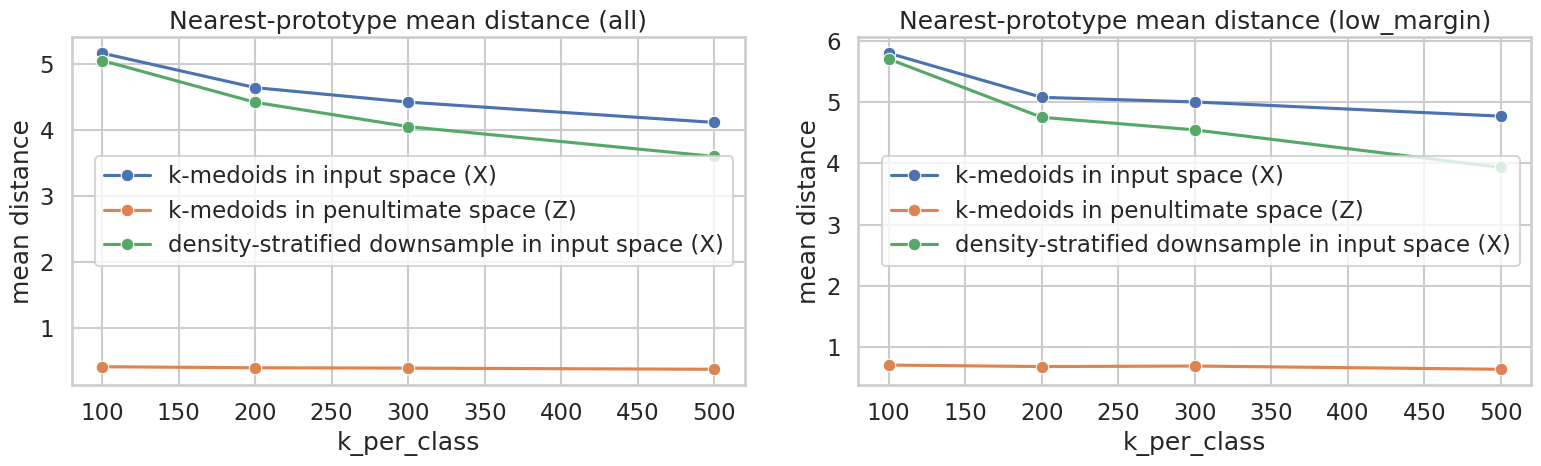

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)
for ax, subset_name, title in [
    (axes[0], 'all', 'Nearest-prototype mean distance (all)'),
    (axes[1], 'low_margin', 'Nearest-prototype mean distance (low_margin)'),
]:
    plot_df = compression_overall[compression_overall['subset'] == subset_name]
    sns.lineplot(data=plot_df, x='k_per_class', y='mean_distance', hue='selection_label', marker='o', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('k_per_class')
    ax.set_ylabel('mean distance')
    ax.legend(loc='best', frameon=True)
plt.tight_layout()
plt.show()


## 3. Certified atlas coverage and overlap

The atlas is built in the original input space for all selectors. This section keeps the unweighted support-coverage metrics exactly comparable to `6.7`.


In [8]:
coverage_rows = []
overlap_rows = []
for dataset_name, bundle in bundles.items():
    for selection_method in ANCHOR_SELECTION_METHODS:
        for k in K_GRID:
            coverage_rows.extend(_coverage_rows(bundle, selection_method, k))
            overlap_rows.extend(_overlap_rows(bundle, selection_method, k))

coverage_df = pd.DataFrame(coverage_rows)
overlap_df = pd.DataFrame(overlap_rows)
coverage_overall = coverage_df[coverage_df['class_label'].eq('overall')].copy()
overlap_overall = overlap_df[overlap_df['class_label'].eq('overall')].copy()

display(coverage_overall.sort_values(['dataset', 'k_per_class', 'selection_method']))
display(overlap_overall.sort_values(['dataset', 'k_per_class', 'selection_method']))


Computing bounds:   0%|          | 0/2 [00:00<?, ?it/s]/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/auto_LiRPA/perturbations.py:199: RuntimeWarning: divide by zero encountered in scalar divide
  self.dual_norm = 1 if (norm == np.inf) else (np.float64(1.0) / (1 - 1.0 / self.norm))
/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/auto_LiRPA/operators/linear.py:650: RuntimeWarning: divide by zero encountered in scalar divide
  dual_norm = np.float64(1.0) / (1 - 1.0 / norm)
Computing bounds: 100%|██████████| 2/2 [00:12<00:00,  6.12s/it]


,dataset,selection_method,selection_label,selection_space,class_label,k_per_class,n_eval,n_covered,coverage_rate,build_time_s,n_selected_total
26,adult,density_stratified_x,density-stratified downsample in input space (X),input_space,overall,100,8000,62,0.007750,2.482060,200
2,adult,kmedoids_x,k-medoids in input space (X),input_space,overall,100,8000,241,0.030125,2.655309,200
14,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,overall,100,8000,122,0.015250,2.435590,200
29,adult,density_stratified_x,density-stratified downsample in input space (X),input_space,overall,200,8000,139,0.017375,4.879273,400
5,adult,kmedoids_x,k-medoids in input space (X),input_space,overall,200,8000,332,0.041500,4.757811,400
17,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,overall,200,8000,193,0.024125,5.068062,400
32,adult,density_stratified_x,density-stratified downsample in input space (X),input_space,overall,300,8000,213,0.026625,7.434135,600
8,adult,kmedoids_x,k-medoids in input space (X),input_space,overall,300,8000,386,0.048250,7.131026,600
20,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,overall,300,8000,225,0.028125,7.477157,600
35,adult,density_stratified_x,density-stratified downsample in input space (X),input_space,overall,500,8000,323,0.040375,12.266926,1000


,dataset,selection_method,selection_label,selection_space,class_label,k_per_class,n_eval,covered_rate,multi_cover_rate,mean_cover_count,mean_cover_count_if_covered,mean_overlap_excess,build_time_s,n_selected_total
26,adult,density_stratified_x,density-stratified downsample in input space (X),input_space,overall,100,8000,0.007750,0.000000,0.007750,1.000000,0.000000,2.482060,200
2,adult,kmedoids_x,k-medoids in input space (X),input_space,overall,100,8000,0.030125,0.003875,0.038000,1.261411,0.007875,2.655309,200
14,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,overall,100,8000,0.015250,0.001625,0.017000,1.114754,0.001750,2.435590,200
29,adult,density_stratified_x,density-stratified downsample in input space (X),input_space,overall,200,8000,0.017375,0.000125,0.017500,1.007194,0.000125,4.879273,400
5,adult,kmedoids_x,k-medoids in input space (X),input_space,overall,200,8000,0.041500,0.003500,0.051875,1.250000,0.010375,4.757811,400
17,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,overall,200,8000,0.024125,0.003500,0.030375,1.259067,0.006250,5.068062,400
32,adult,density_stratified_x,density-stratified downsample in input space (X),input_space,overall,300,8000,0.026625,0.001625,0.028750,1.079812,0.002125,7.434135,600
8,adult,kmedoids_x,k-medoids in input space (X),input_space,overall,300,8000,0.048250,0.006750,0.061875,1.282383,0.013625,7.131026,600
20,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,overall,300,8000,0.028125,0.004250,0.040250,1.431111,0.012125,7.477157,600
35,adult,density_stratified_x,density-stratified downsample in input space (X),input_space,overall,500,8000,0.040375,0.004125,0.046375,1.148607,0.006000,12.266926,1000


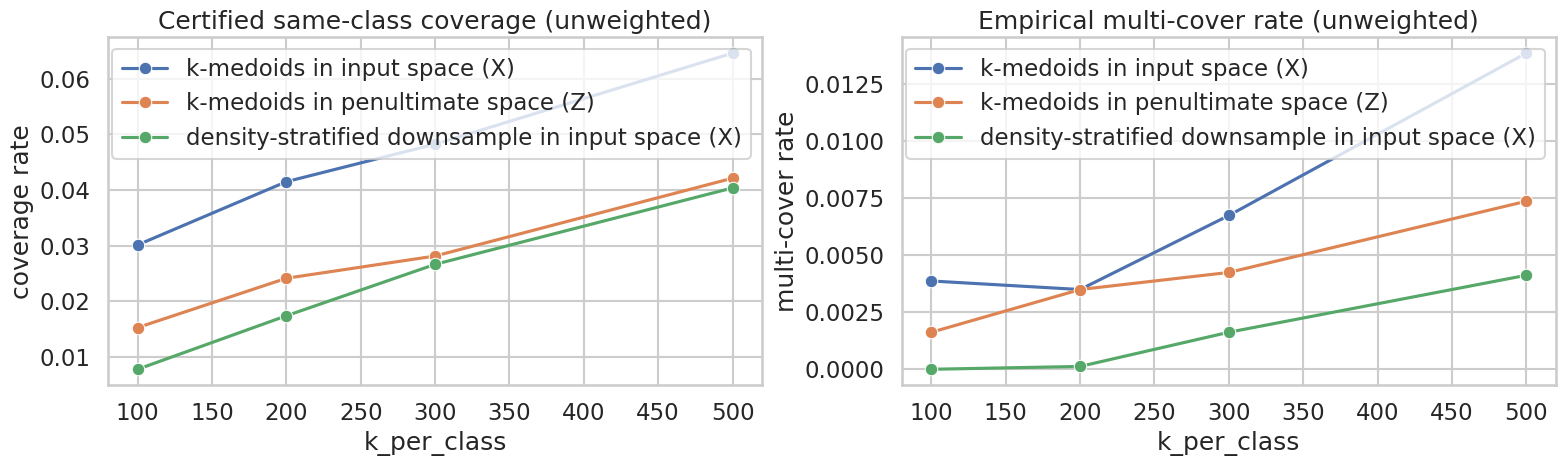

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)
sns.lineplot(data=coverage_overall, x='k_per_class', y='coverage_rate', hue='selection_label', marker='o', ax=axes[0])
axes[0].set_title('Certified same-class coverage (unweighted)')
axes[0].set_xlabel('k_per_class')
axes[0].set_ylabel('coverage rate')

sns.lineplot(data=overlap_overall, x='k_per_class', y='multi_cover_rate', hue='selection_label', marker='o', ax=axes[1])
axes[1].set_title('Empirical multi-cover rate (unweighted)')
axes[1].set_xlabel('k_per_class')
axes[1].set_ylabel('multi-cover rate')

for ax in axes:
    ax.legend(loc='best', frameon=True)
plt.tight_layout()
plt.show()


## 4. Weighted evaluation diagnostics

This section computes alternative summaries on the same sampled support used above:
- inverse-density weighted coverage / overlap summaries
- margin-weighted coverage / overlap summaries

These are alternative views of the same evaluation points, not a second evaluation dataset.


In [10]:
weighted_rows = []
for dataset_name, bundle in bundles.items():
    for selection_method in ANCHOR_SELECTION_METHODS:
        for k in K_GRID:
            weighted_rows.extend(_weighted_support_rows(bundle, selection_method, k))

weighted_support_df = pd.DataFrame(weighted_rows)
weighted_overall = weighted_support_df[weighted_support_df['class_label'].eq('overall')].copy()

display(
    weighted_overall.sort_values(['dataset', 'k_per_class', 'selection_method'])[[
        'dataset', 'selection_method', 'selection_label', 'selection_space', 'k_per_class', 'n_eval',
        'coverage_rate_inverse_density', 'coverage_rate_margin_weighted',
        'mean_overlap_excess_inverse_density', 'mean_overlap_excess_margin_weighted'
    ]]
)

max_diff = max(
    float(np.nanmax(np.abs(weighted_overall['coverage_rate_inverse_density'] - coverage_overall['coverage_rate']))),
    float(np.nanmax(np.abs(weighted_overall['coverage_rate_margin_weighted'] - coverage_overall['coverage_rate']))),
)
if max_diff < 1e-6:
    print('Warning: weighted and unweighted coverage metrics are numerically identical in this run.')
else:
    print({'max_abs_difference_vs_unweighted_coverage': max_diff})


,dataset,selection_method,selection_label,selection_space,k_per_class,n_eval,coverage_rate_inverse_density,coverage_rate_margin_weighted,mean_overlap_excess_inverse_density,mean_overlap_excess_margin_weighted
26,adult,density_stratified_x,density-stratified downsample in input space (X),input_space,100,8000,0.005042,0.006823,0.000000,0.000000
2,adult,kmedoids_x,k-medoids in input space (X),input_space,100,8000,0.013736,0.024895,0.001277,0.009540
14,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,100,8000,0.009850,0.012887,0.000385,0.001955
29,adult,density_stratified_x,density-stratified downsample in input space (X),input_space,200,8000,0.013356,0.012743,0.000029,0.000051
5,adult,kmedoids_x,k-medoids in input space (X),input_space,200,8000,0.018408,0.034502,0.001393,0.014345
17,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,200,8000,0.016692,0.020965,0.001856,0.006767
32,adult,density_stratified_x,density-stratified downsample in input space (X),input_space,300,8000,0.021548,0.019349,0.000815,0.001583
8,adult,kmedoids_x,k-medoids in input space (X),input_space,300,8000,0.021960,0.041276,0.002839,0.014122
20,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,300,8000,0.021069,0.025595,0.003459,0.014080
35,adult,density_stratified_x,density-stratified downsample in input space (X),input_space,500,8000,0.035518,0.027305,0.007009,0.001503


{'max_abs_difference_vs_unweighted_coverage': 0.034630889895541896}


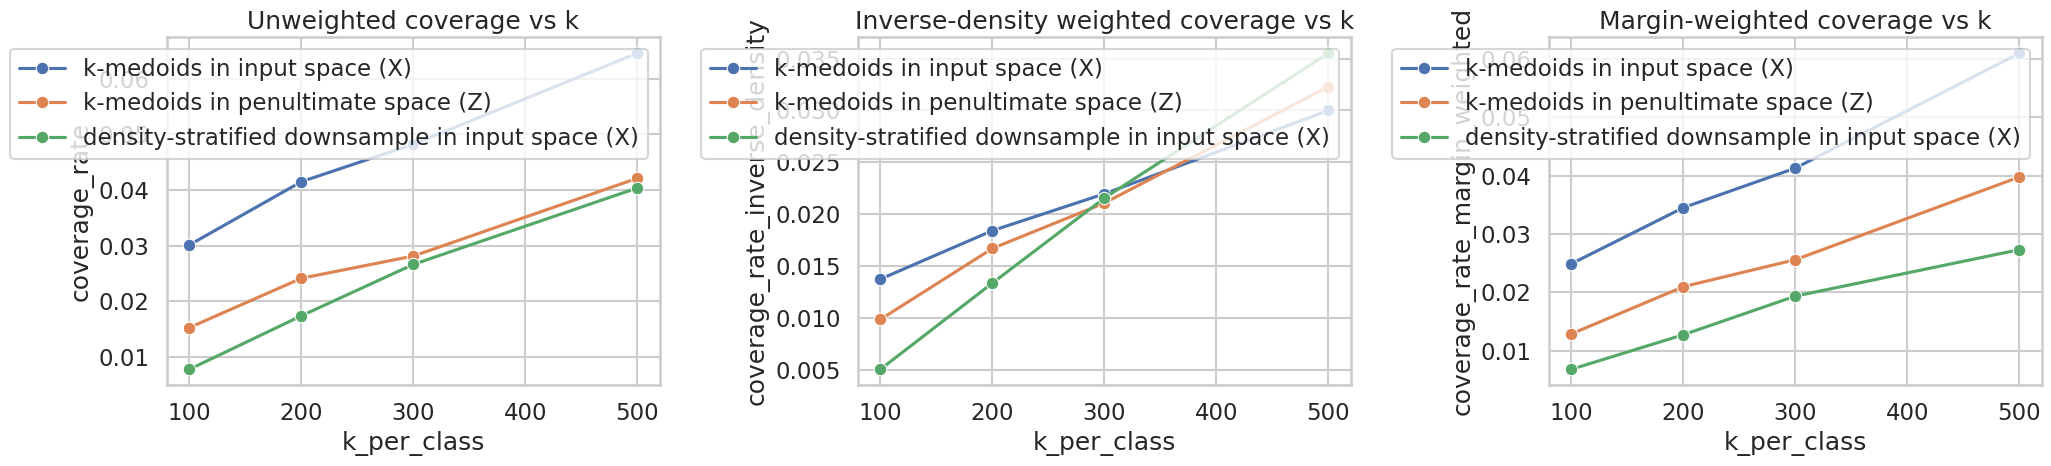

In [11]:
plot_df = coverage_overall.merge(
    weighted_overall[[
        'dataset', 'selection_method', 'selection_label', 'selection_space', 'k_per_class',
        'coverage_rate_inverse_density', 'coverage_rate_margin_weighted'
    ]],
    on=['dataset', 'selection_method', 'selection_label', 'selection_space', 'k_per_class'],
    how='left',
)

fig, axes = plt.subplots(1, 3, figsize=(21, 5), sharex=True)
for ax, metric_name, title in [
    (axes[0], 'coverage_rate', 'Unweighted coverage vs k'),
    (axes[1], 'coverage_rate_inverse_density', 'Inverse-density weighted coverage vs k'),
    (axes[2], 'coverage_rate_margin_weighted', 'Margin-weighted coverage vs k'),
]:
    sns.lineplot(data=plot_df, x='k_per_class', y=metric_name, hue='selection_label', marker='o', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('k_per_class')
    ax.set_ylabel(metric_name)
    ax.legend(loc='best', frameon=True)
plt.tight_layout()
plt.show()


## 5. Pilot query diagnostics

A fixed pilot query set is used to compare end-to-end CertCF behavior under the three anchor-selection rules.

This section keeps the standard pilot metrics and adds a margin-weighted pilot mean distance.


In [12]:
pilot_rows = []
for dataset_name, bundle in bundles.items():
    for selection_method in ANCHOR_SELECTION_METHODS:
        for k in K_GRID:
            pilot_rows.extend(_pilot_query_rows(bundle, selection_method, k))

pilot_df = pd.DataFrame(pilot_rows)
pilot_summary = _pilot_summary_from_df(pilot_df)

display(pilot_summary.sort_values(['dataset', 'k_per_class', 'selection_method']))


/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


,dataset,selection_method,selection_label,selection_space,k_per_class,success_rate,mean_distance,median_distance,pilot_mean_distance_margin_weighted,mean_query_time_ms,median_query_time_ms,build_time_s
0,adult,density_stratified_x,density-stratified downsample in input space (X),input_space,100,1.0,8.274724,8.898294,8.274724,4040.245878,3333.108172,2.482060
4,adult,kmedoids_x,k-medoids in input space (X),input_space,100,1.0,10.133099,11.148364,10.133099,1562.799983,973.686610,2.655309
8,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,100,1.0,8.576207,8.996819,8.576207,1167.636595,901.335662,2.435590
1,adult,density_stratified_x,density-stratified downsample in input space (X),input_space,200,1.0,7.927227,8.176392,7.927227,3537.947126,3776.973948,4.879273
5,adult,kmedoids_x,k-medoids in input space (X),input_space,200,1.0,8.929708,9.407626,8.929708,2128.251067,1907.314079,4.757811
9,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,200,1.0,8.125246,8.430418,8.125246,1537.035334,1439.300728,5.068062
2,adult,density_stratified_x,density-stratified downsample in input space (X),input_space,300,1.0,8.206467,8.539824,8.206467,4278.169434,4122.528409,7.434135
6,adult,kmedoids_x,k-medoids in input space (X),input_space,300,1.0,8.725187,9.046485,8.725187,4212.334979,4073.211038,7.131026
10,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,300,1.0,8.032625,8.248784,8.032625,2863.347012,2333.132431,7.477157
3,adult,density_stratified_x,density-stratified downsample in input space (X),input_space,500,1.0,7.624172,8.036944,7.624172,5681.960620,5165.433757,12.266926


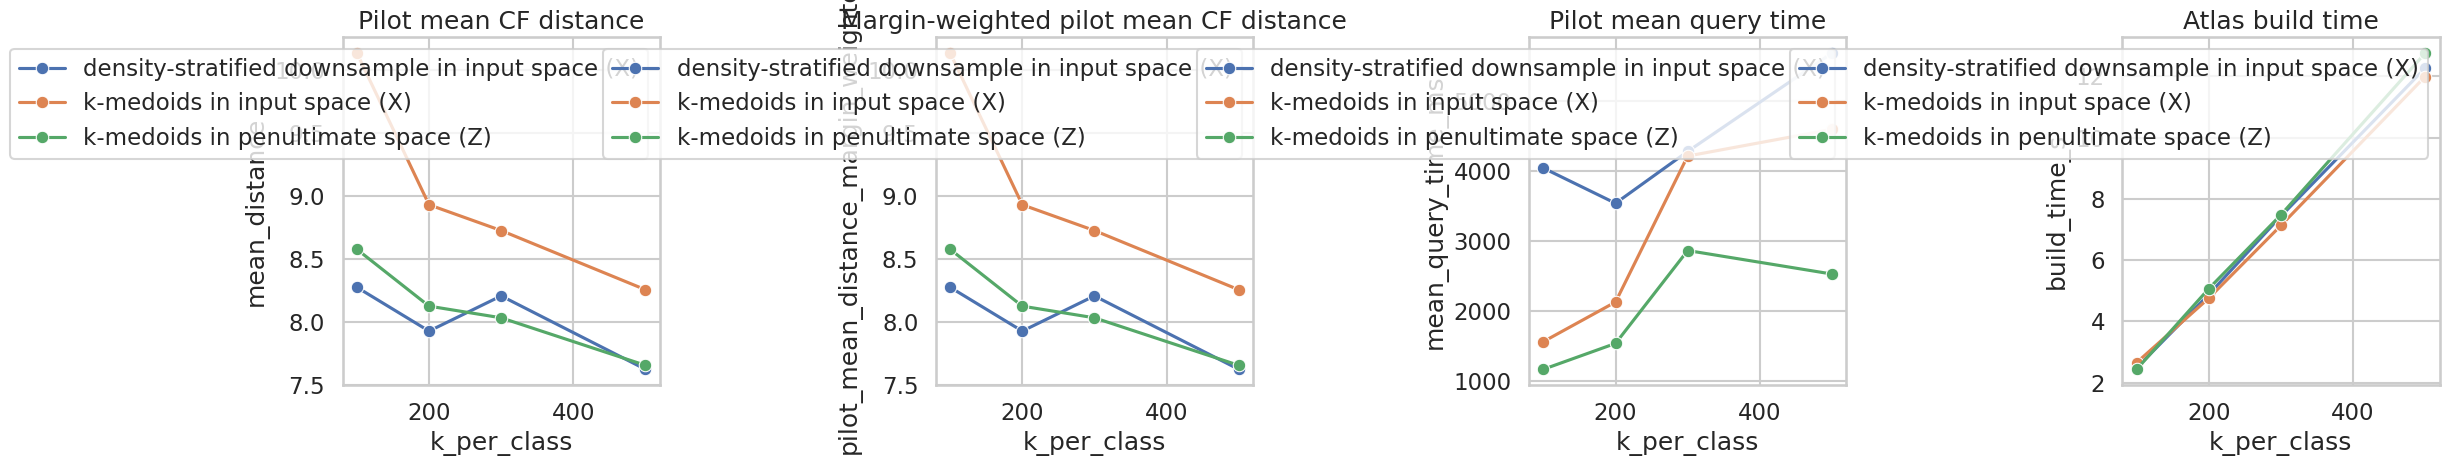

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5), sharex=True)
for ax, metric_name, title in [
    (axes[0], 'mean_distance', 'Pilot mean CF distance'),
    (axes[1], 'pilot_mean_distance_margin_weighted', 'Margin-weighted pilot mean CF distance'),
    (axes[2], 'mean_query_time_ms', 'Pilot mean query time'),
    (axes[3], 'build_time_s', 'Atlas build time'),
]:
    sns.lineplot(data=pilot_summary, x='k_per_class', y=metric_name, hue='selection_label', marker='o', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('k_per_class')
    ax.legend(loc='best', frameon=True)
plt.tight_layout()
plt.show()


## 6. Side-by-side comparison tables

This section merges the main diagnostics into direct comparisons between the baseline `kmedoids_x` atlas and each non-baseline selector.


In [14]:
comparison_df = _make_comparison_table(
    selection_overall=selection_overall,
    compression_overall=compression_overall,
    coverage_overall=coverage_overall,
    overlap_overall=overlap_overall,
    weighted_overall=weighted_overall,
    pilot_summary=pilot_summary,
)

display(comparison_df.sort_values(['dataset', 'k_per_class', 'selection_method_variant']))


,dataset,selection_method_baseline,selection_label_baseline,selection_space_baseline,k_per_class,coverage_rate_baseline,multi_cover_rate_baseline,mean_overlap_excess_baseline,coverage_rate_inverse_density_baseline,coverage_rate_margin_weighted_baseline,...,delta_p95_distance_all,delta_mean_distance_low_margin,delta_p95_distance_low_margin,delta_success_rate,delta_pilot_mean_distance,delta_pilot_median_distance,delta_pilot_mean_distance_margin_weighted,delta_mean_query_time_ms,delta_median_query_time_ms,delta_build_time_s
1,adult,kmedoids_x,k-medoids in input space (X),input_space,100,0.030125,0.003875,0.007875,0.013736,0.024895,...,-0.770032,-0.094772,-0.951393,0.0,-1.858375,-2.250070,-1.858375,2477.445896,2359.421562,-0.173249
0,adult,kmedoids_x,k-medoids in input space (X),input_space,100,0.030125,0.003875,0.007875,0.013736,0.024895,...,-9.462764,-5.087262,-9.663745,0.0,-1.556893,-2.151544,-1.556893,-395.163388,-72.350948,-0.219720
3,adult,kmedoids_x,k-medoids in input space (X),input_space,200,0.041500,0.003500,0.010375,0.018408,0.034502,...,-1.115008,-0.325194,-1.208231,0.0,-1.002481,-1.231234,-1.002481,1409.696058,1869.659869,0.121462
2,adult,kmedoids_x,k-medoids in input space (X),input_space,200,0.041500,0.003500,0.010375,0.018408,0.034502,...,-8.861457,-4.390596,-8.946470,0.0,-0.804462,-0.977208,-0.804462,-591.215733,-468.013351,0.310250
5,adult,kmedoids_x,k-medoids in input space (X),input_space,300,0.048250,0.006750,0.013625,0.021960,0.041276,...,-1.239455,-0.455277,-1.522113,0.0,-0.518721,-0.506661,-0.518721,65.834456,49.317371,0.303109
4,adult,kmedoids_x,k-medoids in input space (X),input_space,300,0.048250,0.006750,0.013625,0.021960,0.041276,...,-8.562648,-4.306813,-8.814449,0.0,-0.692563,-0.797701,-0.692563,-1348.987967,-1740.078607,0.346131
7,adult,kmedoids_x,k-medoids in input space (X),input_space,500,0.064625,0.013875,0.051875,0.029994,0.060956,...,-1.568528,-0.836373,-1.798460,0.0,-0.631607,-0.703944,-0.631607,1088.587639,-91.634988,0.274635
6,adult,kmedoids_x,k-medoids in input space (X),input_space,500,0.064625,0.013875,0.051875,0.029994,0.060956,...,-8.327148,-4.128353,-8.446302,0.0,-0.600039,-1.291454,-0.600039,-2065.759831,-2950.831072,0.764711


## 7. Anchor visualization

For readability, the final visualization reuses the two-panel penultimate-space t-SNE comparison between `kmedoids_x` and `kmedoids_z`. The density-stratified selector is treated numerically in this first notebook version.


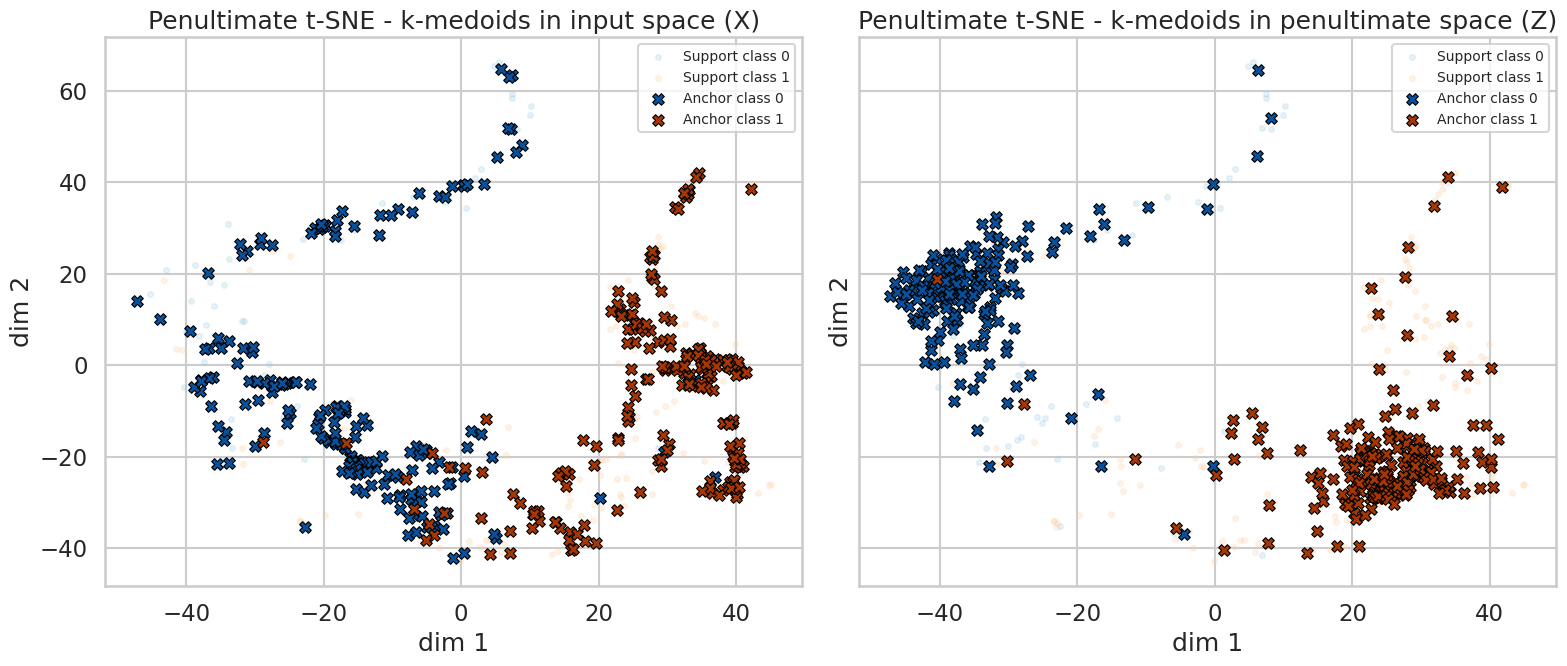

In [15]:
for dataset_name, bundle in bundles.items():
    _plot_penultimate_tsne_views(bundle, visual_k=VISUAL_K)
